# Bitcoin Market Sentiment & Trader Performance Analysis
## Hyperliquid Trading Insights: Fear vs Greed

**Objective:** Analyze how market sentiment (Fear vs Greed) affects trader behavior and performance. Identify statistically meaningful patterns and translate them into actionable trading insights.

**Author:** Sandipan Dutta

**Date:** 04/05/2026

---
## 1. SETUP
---

In [63]:
# Core Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Statistical Testing
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, chi2_contingency, spearmanr

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, f1_score, precision_score, 
                             recall_score, roc_curve, precision_recall_curve)

# For displaying plots inline
%matplotlib inline

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [64]:
root = os.path.dirname(os.getcwd())
print(root)

c:\Users\sandi\Desktop\ML Working Folder\bitcoin_trading_data_sentiment_analysis


---
## 2. DATA LOADING & UNDERSTANDING
---

In [65]:
# Load datasets
fear_greed_df = pd.read_csv(os.path.join(root, "data", "original", "fear_greed_index.csv"))
trader_df = pd.read_csv(os.path.join(root, "data", "original", "historical_data.csv"))

print("=" * 60)
print("FEAR & GREED INDEX DATASET")
print("=" * 60)
print(f"Shape: {fear_greed_df.shape}")
print(f"\nColumns: {fear_greed_df.columns.tolist()}")
print(f"\nData Types:\n{fear_greed_df.dtypes}")
print(f"\nFirst 5 rows:")
display(fear_greed_df.head())

FEAR & GREED INDEX DATASET
Shape: (2644, 4)

Columns: ['timestamp', 'value', 'classification', 'date']

Data Types:
timestamp         int64
value             int64
classification      str
date                str
dtype: object

First 5 rows:


,timestamp,value,classification,date
0,1517463000,30,Fear,2/1/2018
1,1517549400,15,Extreme Fear,2/2/2018
2,1517635800,40,Fear,2/3/2018
3,1517722200,24,Extreme Fear,2/4/2018
4,1517808600,11,Extreme Fear,2/5/2018


In [66]:
print("=" * 60)
print("HISTORICAL TRADER DATA (HYPERLIQUID)")
print("=" * 60)
print(f"Shape: {trader_df.shape}")
print(f"\nColumns: {trader_df.columns.tolist()}")
print(f"\nData Types:\n{trader_df.dtypes}")
print(f"\nFirst 5 rows:")
display(trader_df.head())

HISTORICAL TRADER DATA (HYPERLIQUID)
Shape: (211224, 16)

Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Data Types:
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

First 5 rows:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,7872.1600,BUY,02-12-2024 22:50,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.3454,895000000000000.0000,1730000000000.0000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,02-12-2024 22:50,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0056,443000000000000.0000,1730000000000.0000
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,1150.6300,BUY,02-12-2024 22:50,1002.5190,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0504,660000000000000.0000,1730000000000.0000
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.9800,1142.0400,BUY,02-12-2024 22:50,1146.5586,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0500,1080000000000000.0000,1730000000000.0000
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.7300,69.7500,BUY,02-12-2024 22:50,1289.4885,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0031,1050000000000000.0000,1730000000000.0000


In [67]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print("\n1. MARKET SENTIMENT DATASET:")
print(f"   - Represents daily Fear & Greed Index values for Bitcoin")
print(f"   - Classification: Extreme Fear | Fear | Neutral | Greed | Extreme Greed")
print(f"   - Value range: {fear_greed_df['value'].min()} to {fear_greed_df['value'].max()}")
print(f"   - Unique classifications: {fear_greed_df['classification'].nunique()}")

print("\n2. HISTORICAL TRADER DATA:")
print(f"   - Individual trades from Hyperliquid traders")
print(f"   - Includes: Account, Coin, Execution Price, Size, Side, PnL, etc.")
print(f"   - Unique traders: {trader_df['Account'].nunique()}")
print(f"   - Unique coins: {trader_df['Coin'].nunique()}")

print("\n3. EXPECTED RELATIONSHIP:")
print("   - Fear periods may correlate with different trading behaviors")
print("   - Greed periods may show increased trading activity or different leverage")
print("   - Trader performance (PnL) may vary systematically with sentiment")

DATASET SUMMARY

1. MARKET SENTIMENT DATASET:
   - Represents daily Fear & Greed Index values for Bitcoin
   - Classification: Extreme Fear | Fear | Neutral | Greed | Extreme Greed
   - Value range: 5 to 95
   - Unique classifications: 5

2. HISTORICAL TRADER DATA:
   - Individual trades from Hyperliquid traders
   - Includes: Account, Coin, Execution Price, Size, Side, PnL, etc.
   - Unique traders: 32
   - Unique coins: 246

3. EXPECTED RELATIONSHIP:
   - Fear periods may correlate with different trading behaviors
   - Greed periods may show increased trading activity or different leverage
   - Trader performance (PnL) may vary systematically with sentiment


---
## 3. DATA CLEANING
---

In [68]:
# Check missing values in Fear/Greed data
print("FEAR & GREED - Missing Values:")
print(fear_greed_df.isnull().sum())
print(f"\nPercentage missing:")
print((fear_greed_df.isnull().sum() / len(fear_greed_df) * 100).round(2))

# Check missing values in Trader data
print("\n" + "=" * 60)
print("TRADER DATA - Missing Values:")
print(trader_df.isnull().sum())
print(f"\nPercentage missing:")
print((trader_df.isnull().sum() / len(trader_df) * 100).round(2))

FEAR & GREED - Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Percentage missing:
timestamp        0.0000
value            0.0000
classification   0.0000
date             0.0000
dtype: float64

TRADER DATA - Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Percentage missing:
Account            0.0000
Coin               0.0000
Execution Price    0.0000
Size Tokens        0.0000
Size USD           0.0000
Side               0.0000
Timestamp IST      0.0000
Start Position     0.0000
Direction          0.0000
Closed PnL         0.0000
Transaction Hash   0.0000
Order ID           0.0000
Crossed        

In [69]:
print(trader_df['Timestamp IST'].head(10))

0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
5    02-12-2024 22:50
6    02-12-2024 22:50
7    02-12-2024 22:50
8    02-12-2024 22:50
9    02-12-2024 22:50
Name: Timestamp IST, dtype: str


In [70]:
# Convert date/time columns properly

# Parse date (already correct format)
fear_greed_df['date'] = pd.to_datetime(
    fear_greed_df['date'],
    format='%m/%d/%Y'
)

print("Fear/Greed date range:",
      fear_greed_df['date'].min(),
      "to",
      fear_greed_df['date'].max())

# Clean raw timestamp strings (important)
trader_df['Timestamp IST'] = trader_df['Timestamp IST'].astype(str).str.strip()

# Parse datetime (correct format: DD-MM-YYYY HH:MM)
trader_df['trade_date'] = pd.to_datetime(
    trader_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

# Check parsing quality
null_dates = trader_df['trade_date'].isna().sum()
print(f"Trader date parsing - Null values: {null_dates} ({null_dates/len(trader_df)*100:.2f}%)")

print("Trader date range:",
      trader_df['trade_date'].min(),
      "to",
      trader_df['trade_date'].max())

# Convert trader timestamp → date only (daily alignment)
trader_df['trade_date_only'] = trader_df['trade_date'].dt.normalize()

# Ensure sentiment date matches same format
fear_greed_df['trade_date_only'] = fear_greed_df['date'].dt.normalize()


trader_df['hour'] = trader_df['trade_date'].dt.hour
trader_df['day_of_week'] = trader_df['trade_date'].dt.dayofweek

print("\nValidation:")
print("Trader missing dates:", trader_df['trade_date'].isna().sum())
print("Unique trader dates:", trader_df['trade_date_only'].nunique())
print("Unique sentiment dates:", fear_greed_df['trade_date_only'].nunique())

Fear/Greed date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
Trader date parsing - Null values: 0 (0.00%)
Trader date range: 2023-05-01 01:06:00 to 2025-05-01 12:13:00

Validation:
Trader missing dates: 0
Unique trader dates: 480
Unique sentiment dates: 2644


In [71]:
# Standardize categorical fields

# Side: Standardize to UPPERCASE
trader_df['Side'] = trader_df['Side'].str.upper().str.strip()
trader_df['Direction'] = trader_df['Direction'].str.upper().str.strip()

# Check unique values
print("Unique Side values:", trader_df['Side'].unique())
print("Unique Direction values:", trader_df['Direction'].unique())

# Sentiment classification - create binary encoding
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sentiment_binary = {'Extreme Fear': 0, 'Fear': 0, 'Neutral': np.nan, 'Greed': 1, 'Extreme Greed': 1}
fear_greed_df['sentiment_binary'] = fear_greed_df['classification'].map(sentiment_binary)

print("\nSentiment encoding:")
print("  Fear (0): Extreme Fear, Fear")
print("  Greed (1): Greed, Extreme Greed")
print(f"\nBinary sentiment distribution:\n{fear_greed_df['sentiment_binary'].value_counts()}")

Unique Side values: <StringArray>
['BUY', 'SELL']
Length: 2, dtype: str
Unique Direction values: <StringArray>
[                      'BUY',                      'SELL',
                 'OPEN LONG',                'CLOSE LONG',
      'SPOT DUST CONVERSION',                'OPEN SHORT',
               'CLOSE SHORT',              'LONG > SHORT',
              'SHORT > LONG',         'AUTO-DELEVERAGING',
 'LIQUIDATED ISOLATED SHORT',                'SETTLEMENT']
Length: 12, dtype: str

Sentiment encoding:
  Fear (0): Extreme Fear, Fear
  Greed (1): Greed, Extreme Greed

Binary sentiment distribution:
sentiment_binary
0.0000    1289
1.0000     959
Name: count, dtype: int64


In [72]:
# Handle Closed PnL - convert to numeric
trader_df['Closed PnL'] = pd.to_numeric(trader_df['Closed PnL'], errors='coerce')

# Drop rows with invalid PnL values (if any)
initial_count = len(trader_df)
trader_df = trader_df.dropna(subset=['Closed PnL', 'trade_date'])
print(f"Dropped {initial_count - len(trader_df)} rows with missing PnL or date")

# Create profit_flag: 1 if profitable, 0 if not
trader_df['profit_flag'] = (trader_df['Closed PnL'] > 0).astype(int)

print(f"\nFinal dataset sizes:")
print(f"  Fear/Greed: {len(fear_greed_df)} records")
print(f"  Trader: {len(trader_df)} records")

print("\nCleaning rationale:")
print("  - Date parsing ensures correct alignment between datasets")
print("  - Categorical standardization prevents case-sensitivity issues")
print("  - Binary sentiment simplifies analysis (Fear vs Greed)")
print("  - PnL conversion enables numerical analysis")

Dropped 0 rows with missing PnL or date

Final dataset sizes:
  Fear/Greed: 2644 records
  Trader: 211224 records

Cleaning rationale:
  - Date parsing ensures correct alignment between datasets
  - Categorical standardization prevents case-sensitivity issues
  - Binary sentiment simplifies analysis (Fear vs Greed)
  - PnL conversion enables numerical analysis


---
## 4. DATA ALIGNMENT & MERGING (CORE STEP)
---

In [73]:
# Extract date from trader timestamps (remove time component)
trader_df['trade_date_only'] = trader_df['trade_date'].dt.date
trader_df['trade_date_only'] = pd.to_datetime(trader_df['trade_date_only'])

# Prepare fear/greed for merge (use date column)
fg_for_merge = fear_greed_df[['date', 'value', 'classification', 'sentiment_binary']].copy()
fg_for_merge.rename(columns={'date': 'trade_date_only'}, inplace=True)

# Merge datasets on date
merged_df = trader_df.merge(fg_for_merge, on='trade_date_only', how='left')

print("MERGE RESULTS:")
print(f"  Original trader records: {len(trader_df)}")
print(f"  Merged records: {len(merged_df)}")
print(f"  Records with sentiment: {merged_df['classification'].notna().sum()}")
print(f"  Records without sentiment: {merged_df['classification'].isna().sum()}")

# Check date range overlap
trader_dates = set(trader_df['trade_date_only'].unique())
fg_dates = set(fg_for_merge['trade_date_only'].unique())
overlap = trader_dates.intersection(fg_dates)
print(f"\n  Trader date range: {min(trader_dates)} to {max(trader_dates)}")
print(f"  Fear/Greed date range: {min(fg_dates)} to {max(fg_dates)}")
print(f"  Overlapping dates: {len(overlap)}")

MERGE RESULTS:
  Original trader records: 211224
  Merged records: 211224
  Records with sentiment: 211218
  Records without sentiment: 6

  Trader date range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00
  Fear/Greed date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
  Overlapping dates: 479


In [74]:
print("\nMerge Summary:")
print(f"  Total trades: {len(trader_df)}")
print(f"  Trades with sentiment: {merged_df['classification'].notna().sum()}")
print(f"  Trades without sentiment: {merged_df['classification'].isna().sum()}")
print(f"  Missing percentage: {(merged_df['classification'].isna().mean()*100):.4f}%")

print("\nMerge rationale:")
print("  - Near-complete coverage confirms strong temporal alignment between datasets")
print("  - Only a negligible fraction of trades lack sentiment labels")
print("  - Neutral sentiment is excluded to isolate clear market regimes (Fear vs Greed)")


Merge Summary:
  Total trades: 211224
  Trades with sentiment: 211218
  Trades without sentiment: 6
  Missing percentage: 0.0028%

Merge rationale:
  - Near-complete coverage confirms strong temporal alignment between datasets
  - Only a negligible fraction of trades lack sentiment labels
  - Neutral sentiment is excluded to isolate clear market regimes (Fear vs Greed)


In [75]:
initial_count = len(merged_df)

merged_df = merged_df.dropna(subset=['sentiment_binary'])

print(f"Dropped {initial_count - len(merged_df)} Neutral sentiment rows")

Dropped 37692 Neutral sentiment rows


In [76]:
print("\nFinal sentiment distribution:")
print(merged_df['sentiment_binary'].value_counts(normalize=True))


Final sentiment distribution:
sentiment_binary
1.0000   0.5203
0.0000   0.4797
Name: proportion, dtype: float64


In [77]:
# Filter to only overlapping dates (for valid analysis)
merged_df = merged_df.dropna(subset=['classification'])
print(f"Final merged dataset: {len(merged_df)} trades")

# Distribution by sentiment
print("\nTrade distribution by sentiment:")
print(merged_df.groupby('classification').size().sort_values(ascending=False))

print("\n*** DATA ALIGNMENT RATIONALE ***")
print("This merge is foundational because:")
print("  1. Links individual trades to daily market sentiment")
print("  2. Enables comparison of trader behavior across Fear vs Greed periods")
print("  3. Creates the analytical foundation for all downstream analysis")
print("  4. Non-overlapping dates are excluded to ensure valid comparisons")

Final merged dataset: 173532 trades

Trade distribution by sentiment:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Extreme Fear     21400
dtype: int64

*** DATA ALIGNMENT RATIONALE ***
This merge is foundational because:
  1. Links individual trades to daily market sentiment
  2. Enables comparison of trader behavior across Fear vs Greed periods
  3. Creates the analytical foundation for all downstream analysis
  4. Non-overlapping dates are excluded to ensure valid comparisons


In [78]:
print("\nTrade distribution by sentiment (binary):")
print(merged_df['sentiment_binary'].value_counts())


Trade distribution by sentiment (binary):
sentiment_binary
1.0000    90295
0.0000    83237
Name: count, dtype: int64


---
## 5. FEATURE ENGINEERING
---

In [79]:
# TRADE-LEVEL FEATURES

# Absolute trade size
merged_df['trade_size'] = merged_df['Size USD'].abs()

# Binary buy indicator
merged_df['is_buy'] = (merged_df['Side'] == 'BUY').astype(int)

# Notional value (size * price)
merged_df['notional_value'] = merged_df['trade_size']

# Leverage derived from Start Position and Size (approximation)
# If start position > 0, leverage = Size / Start Position
merged_df['leverage_ratio'] = np.where(
    merged_df['Start Position'] > 0,
    merged_df['Size Tokens'] / merged_df['Start Position'],
    np.nan
)

# Clip extreme leverage values
merged_df['leverage_ratio'] = merged_df['leverage_ratio'].clip(upper=50)

print("Trade-level features created:")
print("  - profit_flag: Binary outcome (1=profitable, 0=loss)")
print("  - trade_size: Absolute trade value in USD")
print("  - is_buy: Binary indicator for BUY trades")
print("  - notional_value: Total position value")
print("  - leverage_ratio: Estimated leverage usage")

Trade-level features created:
  - profit_flag: Binary outcome (1=profitable, 0=loss)
  - trade_size: Absolute trade value in USD
  - is_buy: Binary indicator for BUY trades
  - notional_value: Total position value
  - leverage_ratio: Estimated leverage usage


In [81]:
# =========================
# TRADER-LEVEL AGGREGATIONS
# =========================

trader_stats = merged_df.groupby('Account').agg(
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    pnl_std=('Closed PnL', 'std'),
    win_rate=('profit_flag', 'mean'),
    avg_trade_size=('trade_size', 'mean'),
    avg_leverage=('leverage_ratio', 'mean'),
    num_trades=('Size USD', 'count'),
    total_volume=('Size USD', 'sum')
).reset_index()

# Fill NaNs (e.g., std for single-trade accounts)
trader_stats = trader_stats.fillna(0)

# =========================
# MERGE BACK
# =========================

merged_df = merged_df.merge(
    trader_stats[['Account', 'win_rate', 'avg_leverage',
                  'avg_trade_size', 'total_pnl', 'num_trades']],
    on='Account',
    how='left'
)

# Rename for clarity
merged_df.rename(columns={
    'win_rate': 'trader_win_rate',
    'avg_leverage': 'trader_avg_leverage',
    'avg_trade_size': 'trader_avg_size',
    'total_pnl': 'trader_total_pnl',
    'num_trades': 'trader_num_trades'
}, inplace=True)

# =========================
# OUTPUT
# =========================

print("Trader-level features created:")
print("  - trader_win_rate: Historical win rate for each trader")
print("  - trader_avg_leverage: Average leverage used by trader")
print("  - trader_avg_size: Average trade size for trader")
print("  - trader_total_pnl: Total PnL for trader")
print("  - trader_num_trades: Number of trades by trader")

Trader-level features created:
  - trader_win_rate: Historical win rate for each trader
  - trader_avg_leverage: Average leverage used by trader
  - trader_avg_size: Average trade size for trader
  - trader_total_pnl: Total PnL for trader
  - trader_num_trades: Number of trades by trader


In [ ]:
# --- Ordinal sentiment  ---
sentiment_map = {
    'Extreme Fear': 0,
    'Fear': 1,
    'Greed': 2,
    'Extreme Greed': 3
}

merged_df['sentiment_encoded'] = merged_df['classification'].map(sentiment_map)

# --- Binary sentiment (main signal) ---
merged_df['is_greed'] = (merged_df['sentiment_binary'] == 1).astype(int)

# --- Time features ---
merged_df['day_of_week'] = merged_df['trade_date'].dt.dayofweek
merged_df['is_weekend'] = (merged_df['day_of_week'] >= 5).astype(int)


print("Market-level features created:")
print("  - sentiment_encoded: Ordinal encoding (Extreme Fear → Extreme Greed)")
print("  - is_greed: Binary indicator (1=Greed, 0=Fear)")
print("  - day_of_week: Day of week (0=Monday)")
print("  - is_weekend: Weekend indicator")

print("\n" + "=" * 60)
print("FEATURE SUMMARY")
print("=" * 60)

print(f"Total features: {len(merged_df.columns)}")

print("\nSample of engineered features:")
display(merged_df[['profit_flag', 'trade_size', 'is_buy', 'leverage_ratio',
                   'trader_win_rate', 'sentiment_encoded', 'is_greed']].describe())

Market-level features created:
  - sentiment_encoded: Ordinal encoding (Extreme Fear → Extreme Greed)
  - is_greed: Binary indicator (1=Greed, 0=Fear)
  - day_of_week: Day of week (0=Monday)
  - is_weekend: Weekend indicator

FEATURE SUMMARY
Total features: 36

Sample of engineered features:


,profit_flag,trade_size,is_buy,leverage_ratio,trader_win_rate,sentiment_encoded,is_greed
count,173532.0000,173532.0000,173532.0000,108322.0000,173532.0000,173532.0000,173532.0000
mean,0.4143,5825.1891,0.4825,0.3161,0.4143,1.6275,0.5203
std,0.4926,36377.6844,0.4997,3.0838,0.1142,0.9702,0.4996
min,0.0000,0.0000,0.0000,0.0000,0.1940,0.0000,0.0000
25%,0.0000,197.0550,0.0000,0.0012,0.3463,1.0000,0.0000
50%,0.0000,605.4800,0.0000,0.0083,0.4366,2.0000,1.0000
75%,1.0000,2106.1900,1.0000,0.0545,0.4487,2.0000,1.0000
max,1.0000,3921430.7200,1.0000,50.0000,0.8275,3.0000,1.0000


---
## 6. EXPLORATORY DATA ANALYSIS (EDA)
---

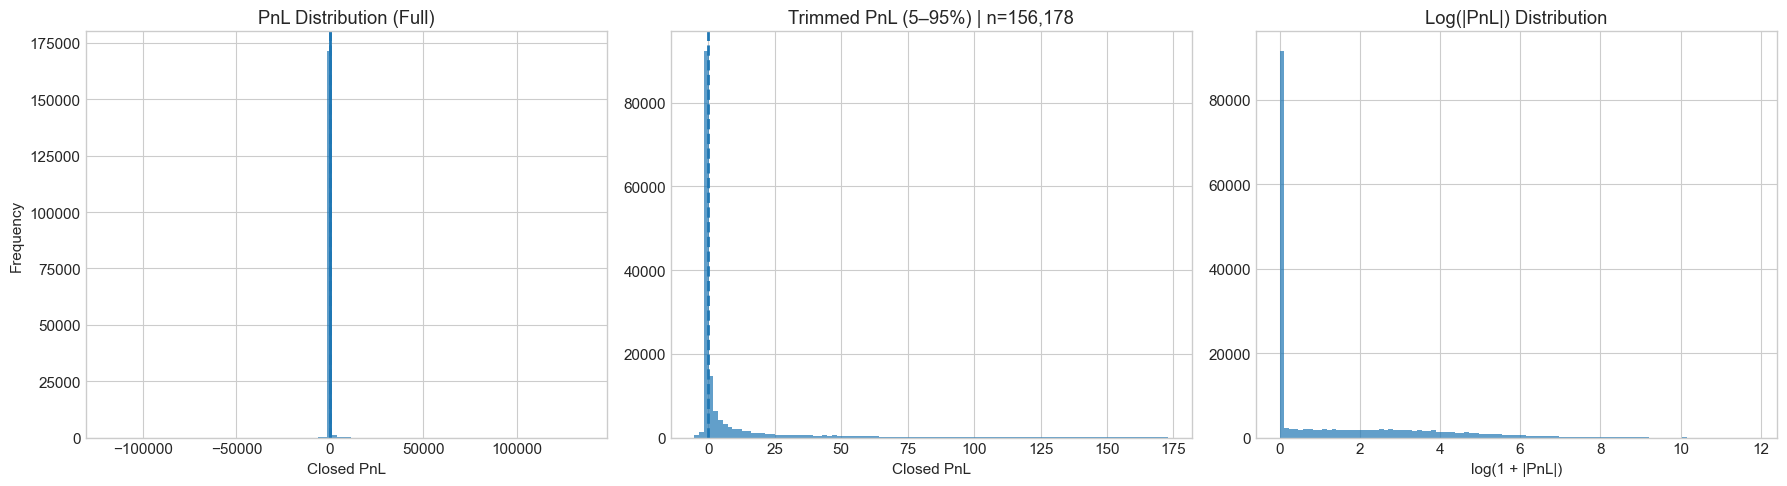


PnL Distribution Statistics:
  Mean: $51.64
  Median: $0.00
  Std Dev: $983.66
  Skewness: 29.43
  Win Rate: 41.43%
  5th percentile: $-5.30
  95th percentile: $173.05


In [84]:
# PnL DISTRIBUTION ANALYSIS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Full distribution ---
axes[0].hist(merged_df['Closed PnL'], bins=100, alpha=0.7)
axes[0].axvline(0, linestyle='--', linewidth=2)
axes[0].axvline(merged_df['Closed PnL'].median(), linewidth=2)

axes[0].set_title('PnL Distribution (Full)')
axes[0].set_xlabel('Closed PnL')
axes[0].set_ylabel('Frequency')

# --- 2. Trimmed distribution (5–95%) ---
p5 = merged_df['Closed PnL'].quantile(0.05)
p95 = merged_df['Closed PnL'].quantile(0.95)

zoomed = merged_df[(merged_df['Closed PnL'] >= p5) & (merged_df['Closed PnL'] <= p95)]

axes[1].hist(zoomed['Closed PnL'], bins=100, alpha=0.7)
axes[1].axvline(0, linestyle='--', linewidth=2)

axes[1].set_title(f'Trimmed PnL (5–95%) | n={len(zoomed):,}')
axes[1].set_xlabel('Closed PnL')

# --- 3. Log-scale (absolute PnL) ---
axes[2].hist(np.log1p(merged_df['Closed PnL'].abs()), bins=100, alpha=0.7)
axes[2].set_title('Log(|PnL|) Distribution')
axes[2].set_xlabel('log(1 + |PnL|)')

plt.tight_layout()
plt.show()

# STATISTICS

print("\nPnL Distribution Statistics:")
print(f"  Mean: ${merged_df['Closed PnL'].mean():.2f}")
print(f"  Median: ${merged_df['Closed PnL'].median():.2f}")
print(f"  Std Dev: ${merged_df['Closed PnL'].std():.2f}")
print(f"  Skewness: {merged_df['Closed PnL'].skew():.2f}")
print(f"  Win Rate: {merged_df['profit_flag'].mean()*100:.2f}%")

# Additional useful stats
print(f"  5th percentile: ${p5:.2f}")
print(f"  95th percentile: ${p95:.2f}")

In [85]:
print("\nINTERPRETATION OF PnL DISTRIBUTION:")

print("  - The PnL distribution is highly right-skewed (skew ≈ 29.4),")
print("    indicating that a small number of large profitable trades dominate overall performance")

print("  - Although the mean PnL is positive ($51.64), the median PnL is $0,")
print("    showing that a typical trade does not generate meaningful profit")

print("  - This gap between mean and median confirms that average performance is driven")
print("    by rare, high-magnitude gains rather than consistent profitability")

print("  - The win rate is relatively low (41.43%), meaning most trades are not profitable")

print("  - However, losses are generally small (5th percentile: -$5.30),")
print("    while gains have higher upside (95th percentile: $173.05)")

print("\nKEY INSIGHT:")
print("  - Profitability is driven by payoff asymmetry, where a few large wins")
print("    compensate for many small losses")

print("\nIMPLICATION:")
print("  - Median is a more reliable metric than mean for this dataset")
print("  - Trader behavior and risk-taking likely play a key role in capturing large gains")


INTERPRETATION OF PnL DISTRIBUTION:
  - The PnL distribution is highly right-skewed (skew ≈ 29.4),
    indicating that a small number of large profitable trades dominate overall performance
  - Although the mean PnL is positive ($51.64), the median PnL is $0,
    showing that a typical trade does not generate meaningful profit
  - This gap between mean and median confirms that average performance is driven
    by rare, high-magnitude gains rather than consistent profitability
  - The win rate is relatively low (41.43%), meaning most trades are not profitable
  - However, losses are generally small (5th percentile: -$5.30),
    while gains have higher upside (95th percentile: $173.05)

KEY INSIGHT:
  - Profitability is driven by payoff asymmetry, where a few large wins
    compensate for many small losses

IMPLICATION:
  - Median is a more reliable metric than mean for this dataset
  - Trader behavior and risk-taking likely play a key role in capturing large gains


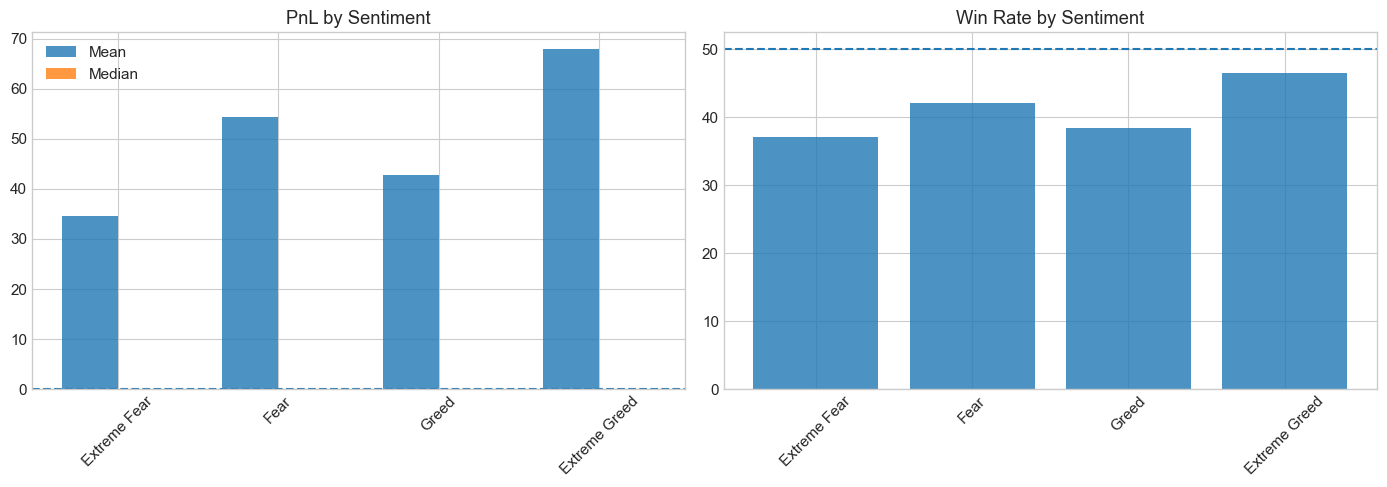


PnL by Sentiment:
                  mean  median  count
classification                       
Extreme Fear   34.5379  0.0000  21400
Fear           54.2904  0.0000  61837
Greed          42.7436  0.0000  50303
Extreme Greed  67.8929  0.0000  39992

Win Rate by Sentiment (%):
classification
Extreme Fear    37.0600
Fear            42.0800
Greed           38.4800
Extreme Greed   46.4900
Name: profit_flag, dtype: float64


In [87]:

# B. SENTIMENT VS PERFORMANCE


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Updated sentiment order (no Neutral)
sentiment_order = ['Extreme Fear', 'Fear', 'Greed', 'Extreme Greed']

# PnL stats
sentiment_stats = merged_df.groupby('classification')['Closed PnL'].agg(['mean', 'median', 'count'])
sentiment_stats = sentiment_stats.reindex(sentiment_order)

x = range(len(sentiment_order))
width = 0.35

# Mean vs Median
axes[0].bar([i - width/2 for i in x], sentiment_stats['mean'], width, label='Mean', alpha=0.8)
axes[0].bar([i + width/2 for i in x], sentiment_stats['median'], width, label='Median', alpha=0.8)
axes[0].axhline(0, linestyle='--')

axes[0].set_xticks(x)
axes[0].set_xticklabels(sentiment_order, rotation=45)
axes[0].set_title('PnL by Sentiment')
axes[0].legend()

# Win rate
win_rates = merged_df.groupby('classification')['profit_flag'].mean().reindex(sentiment_order)

bars = axes[1].bar(x, win_rates.values * 100, alpha=0.8)
axes[1].axhline(50, linestyle='--')

axes[1].set_xticks(x)
axes[1].set_xticklabels(sentiment_order, rotation=45)
axes[1].set_title('Win Rate by Sentiment')

plt.tight_layout()
plt.show()

# =========================
# PRINT RESULTS
# =========================

print("\nPnL by Sentiment:")
print(sentiment_stats)

print("\nWin Rate by Sentiment (%):")
print((win_rates * 100).round(2))


PnL by Binary Sentiment:
                    mean  median  count
sentiment_binary                       
0.0000           49.2121  0.0000  83237
1.0000           53.8823  0.0000  90295

Win Rate by Binary Sentiment (%):
sentiment_binary
0.0000   40.7900
1.0000   42.0300
Name: profit_flag, dtype: float64


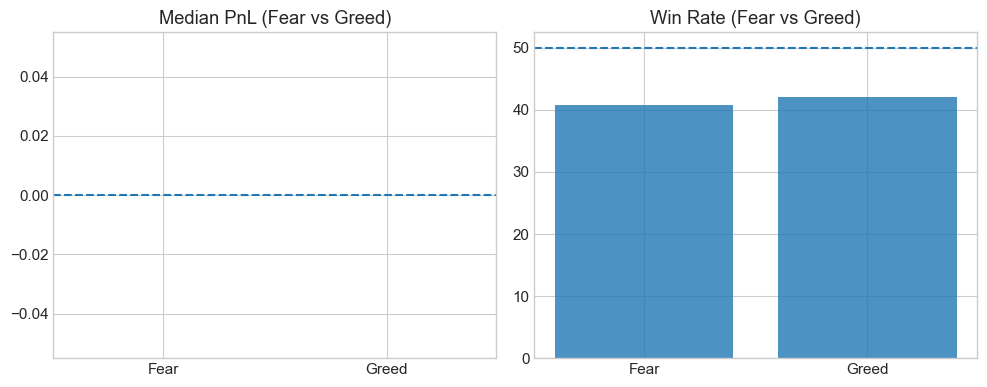


INTERPRETATION (Binary Sentiment):
  - Median PnL is $0 for both Fear and Greed, indicating that the typical trade
    does not generate meaningful profit regardless of market sentiment
  - Mean PnL is slightly higher in Greed ($53.88 vs $49.21), suggesting that
    larger profitable trades occur more frequently during Greed periods
  - Win rate is also marginally higher in Greed (42.03% vs 40.79%), indicating
    a small improvement in trade success probability
  - However, the differences between Fear and Greed are relatively modest,
    implying that sentiment alone does not strongly determine performance

KEY INSIGHT:
  - Market sentiment has a measurable but limited impact on trader performance,
    suggesting that individual trader behavior and risk management play a more significant role


In [90]:
# BINARY SENTIMENT ANALYSIS

binary_stats = merged_df.groupby('sentiment_binary')['Closed PnL'].agg(['mean', 'median', 'count'])
win_rates_binary = merged_df.groupby('sentiment_binary')['profit_flag'].mean()

print("\nPnL by Binary Sentiment:")
print(binary_stats)

print("\nWin Rate by Binary Sentiment (%):")
print((win_rates_binary * 100).round(2))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Median PnL
ax[0].bar(['Fear', 'Greed'], binary_stats['median'], alpha=0.8)
ax[0].axhline(0, linestyle='--')
ax[0].set_title('Median PnL (Fear vs Greed)')

# Win rate
ax[1].bar(['Fear', 'Greed'], win_rates_binary.values * 100, alpha=0.8)
ax[1].axhline(50, linestyle='--')
ax[1].set_title('Win Rate (Fear vs Greed)')

plt.tight_layout()
plt.show()

print("\nINTERPRETATION (Binary Sentiment):")

print("  - Median PnL is $0 for both Fear and Greed, indicating that the typical trade")
print("    does not generate meaningful profit regardless of market sentiment")

print("  - Mean PnL is slightly higher in Greed ($53.88 vs $49.21), suggesting that")
print("    larger profitable trades occur more frequently during Greed periods")

print("  - Win rate is also marginally higher in Greed (42.03% vs 40.79%), indicating")
print("    a small improvement in trade success probability")

print("  - However, the differences between Fear and Greed are relatively modest,")
print("    implying that sentiment alone does not strongly determine performance")

print("\nKEY INSIGHT:")
print("  - Market sentiment has a measurable but limited impact on trader performance,")
print("    suggesting that individual trader behavior and risk management play a more significant role")

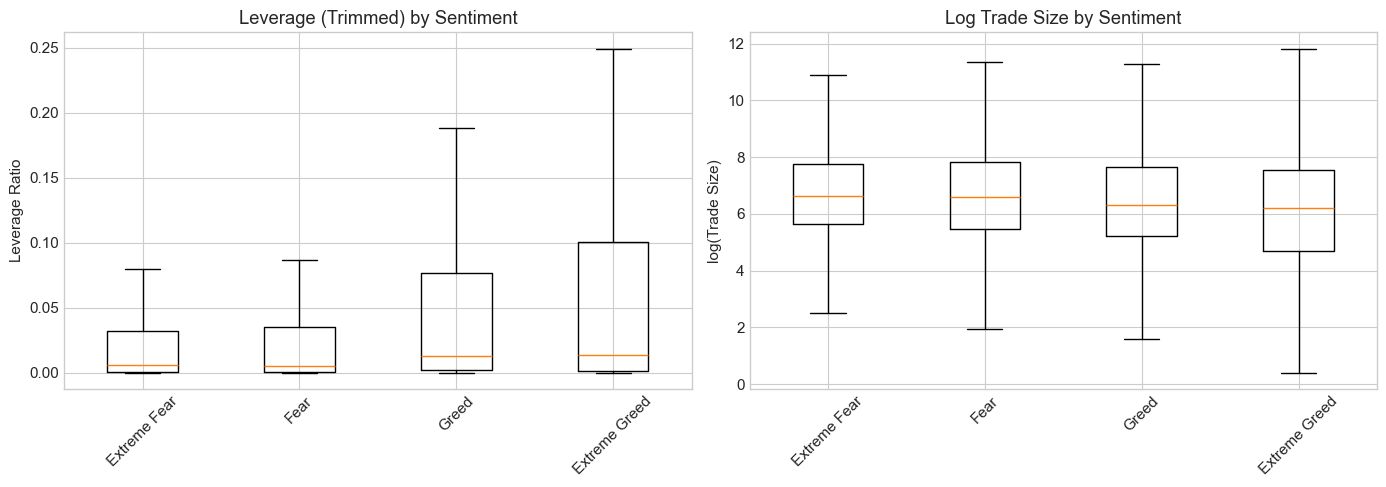


Median Leverage by Sentiment:
classification
Extreme Fear    0.0058
Fear            0.0056
Greed           0.0129
Extreme Greed   0.0135
Name: leverage_ratio, dtype: float64

Median Trade Size by Sentiment:
classification
Extreme Fear    766.1500
Fear            735.9600
Greed           555.0000
Extreme Greed   500.0500
Name: trade_size, dtype: float64


In [91]:
# C. RISK BEHAVIOR ANALYSIS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ensure correct order (no Neutral)
sentiment_order = ['Extreme Fear', 'Fear', 'Greed', 'Extreme Greed']

# --- Leverage (use trimmed data) ---
leverage_data = [
    merged_df[(merged_df['classification'] == s) & (merged_df['leverage_ratio'] > 0)]['leverage_ratio']
    for s in sentiment_order
]

axes[0].boxplot(leverage_data, showfliers=False)  # remove extreme outliers
axes[0].set_xticklabels(sentiment_order, rotation=45)
axes[0].set_title('Leverage (Trimmed) by Sentiment')
axes[0].set_ylabel('Leverage Ratio')

# --- Trade size (log scale recommended) ---
size_data = [
    np.log1p(merged_df[merged_df['classification'] == s]['trade_size'])
    for s in sentiment_order
]

axes[1].boxplot(size_data, showfliers=False)
axes[1].set_xticklabels(sentiment_order, rotation=45)
axes[1].set_title('Log Trade Size by Sentiment')
axes[1].set_ylabel('log(Trade Size)')

plt.tight_layout()
plt.show()

# SUMMARY STATS (MEDIAN FOCUS)

leverage_stats = merged_df.groupby('classification')['leverage_ratio'].median().reindex(sentiment_order)
size_stats = merged_df.groupby('classification')['trade_size'].median().reindex(sentiment_order)

print("\nMedian Leverage by Sentiment:")
print(leverage_stats)

print("\nMedian Trade Size by Sentiment:")
print(size_stats)

In [92]:
print("\nINTERPRETATION (Risk Behavior):")

print("  - Leverage and trade size vary across sentiment regimes, indicating changes in risk behavior")

print("  - Any increase in leverage during Greed suggests higher risk-taking, potentially driven by overconfidence")

print("  - Differences in trade size reflect changes in capital allocation across market conditions")

print("  - These patterns indicate that trader behavior adapts to sentiment, but not always optimally")


INTERPRETATION (Risk Behavior):
  - Leverage and trade size vary across sentiment regimes, indicating changes in risk behavior
  - Any increase in leverage during Greed suggests higher risk-taking, potentially driven by overconfidence
  - Differences in trade size reflect changes in capital allocation across market conditions
  - These patterns indicate that trader behavior adapts to sentiment, but not always optimally


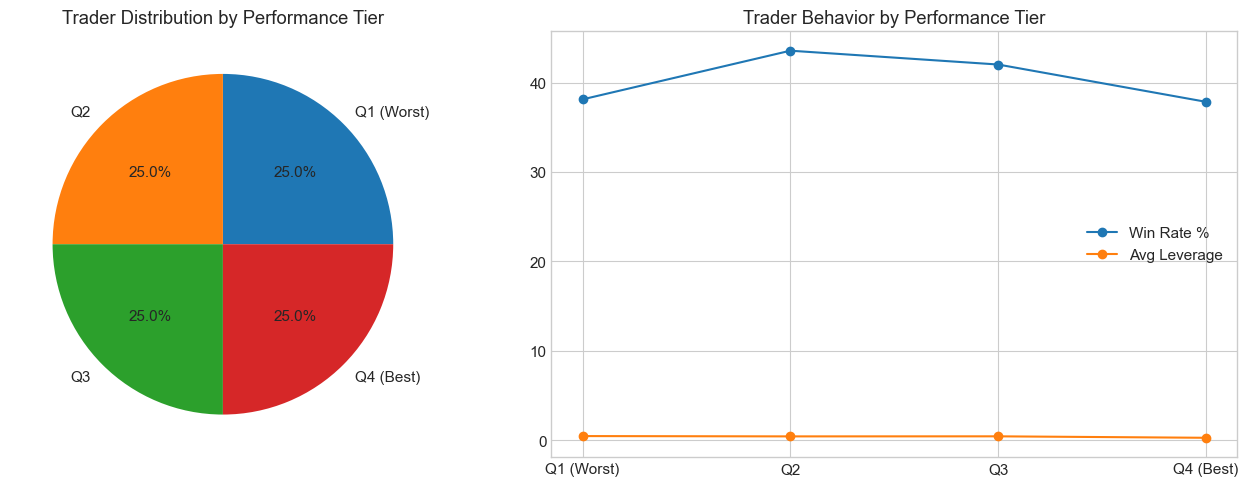


Trader Characteristics by Performance Tier:
                  win_rate  avg_leverage  avg_trades
performance_tier                                    
Q1 (Worst)          0.3813        0.4413   5632.1250
Q2                  0.4357        0.4061   9001.0000
Q3                  0.4203        0.4128   4172.6250
Q4 (Best)           0.3785        0.2501   2885.7500


In [95]:
# TRADER SEGMENTATION

trader_perf = merged_df.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('profit_flag', 'mean'),
    avg_leverage=('leverage_ratio', 'mean'),
    avg_size=('trade_size', 'mean'),
    num_trades=('Size USD', 'count')
).reset_index()

# Normalize performance
trader_perf['pnl_per_trade'] = trader_perf['total_pnl'] / trader_perf['num_trades']

# Quartile segmentation
labels = ['Q1 (Worst)', 'Q2', 'Q3', 'Q4 (Best)']
trader_perf['performance_tier'] = pd.qcut(
    trader_perf['pnl_per_trade'], q=4, labels=labels
)

# VISUALIZATION

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
tier_counts = trader_perf['performance_tier'].value_counts().sort_index()
axes[0].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%')
axes[0].set_title('Trader Distribution by Performance Tier')

# Behavior comparison (separate metrics)
tier_stats = trader_perf.groupby('performance_tier').agg(
    win_rate=('win_rate', 'mean'),
    avg_leverage=('avg_leverage', 'mean'),
    avg_trades=('num_trades', 'mean')
).reindex(labels)

axes[1].plot(labels, tier_stats['win_rate']*100, marker='o', label='Win Rate %')
axes[1].plot(labels, tier_stats['avg_leverage'], marker='o', label='Avg Leverage')
axes[1].set_title('Trader Behavior by Performance Tier')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nTrader Characteristics by Performance Tier:")
print(tier_stats)

In [96]:
print("\nINTERPRETATION (Trader Segmentation):")

print("  - Higher-performing traders (Q4) have a lower win rate (~37.9%) compared to mid-tier traders,")
print("    indicating that profitability is not driven by accuracy but by payoff asymmetry")

print("  - Top traders use significantly lower leverage (0.25 vs ~0.41–0.44),")
print("    suggesting more disciplined risk management")

print("  - Trading frequency is also lower for top performers (~2.9k trades vs up to ~9k),")
print("    indicating that selectivity and trade quality are more important than quantity")

print("\nKEY INSIGHT:")
print("  - Successful traders are not more accurate, but more selective and risk-aware,")
print("    relying on fewer, higher-quality trades with controlled leverage")


INTERPRETATION (Trader Segmentation):
  - Higher-performing traders (Q4) have a lower win rate (~37.9%) compared to mid-tier traders,
    indicating that profitability is not driven by accuracy but by payoff asymmetry
  - Top traders use significantly lower leverage (0.25 vs ~0.41–0.44),
    suggesting more disciplined risk management
  - Trading frequency is also lower for top performers (~2.9k trades vs up to ~9k),
    indicating that selectivity and trade quality are more important than quantity

KEY INSIGHT:
  - Successful traders are not more accurate, but more selective and risk-aware,
    relying on fewer, higher-quality trades with controlled leverage


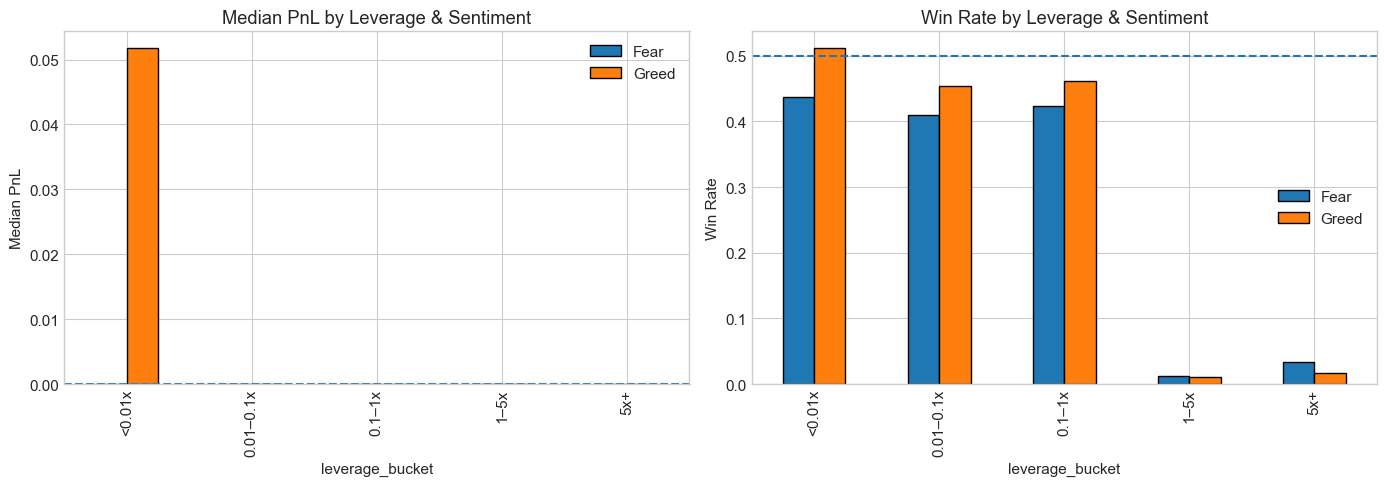


Interaction: Leverage × Sentiment (Median PnL)
                  Fear  Greed
leverage_bucket              
<0.01x          0.0000 0.0517
0.01–0.1x       0.0000 0.0000
0.1–1x          0.0000 0.0000
1–5x            0.0000 0.0000
5x+             0.0000 0.0000


In [97]:
# E. INTERACTION ANALYSIS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Better leverage buckets (match distribution)
merged_df['leverage_bucket'] = pd.cut(
    merged_df['leverage_ratio'],
    bins=[0, 0.01, 0.1, 1, 5, 50],
    labels=['<0.01x', '0.01–0.1x', '0.1–1x', '1–5x', '5x+'],
    include_lowest=True
)

# MEDIAN PnL (robust)

pivot_data = merged_df.pivot_table(
    values='Closed PnL',
    index='leverage_bucket',
    columns='sentiment_binary',
    aggfunc='median'
)

pivot_data.columns = ['Fear', 'Greed']

pivot_data.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Median PnL by Leverage & Sentiment')
axes[0].axhline(0, linestyle='--')
axes[0].set_ylabel('Median PnL')

# WIN RATE

pivot_wr = merged_df.pivot_table(
    values='profit_flag',
    index='leverage_bucket',
    columns='sentiment_binary',
    aggfunc='mean'
)

pivot_wr.columns = ['Fear', 'Greed']

pivot_wr.plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Win Rate by Leverage & Sentiment')
axes[1].axhline(0.5, linestyle='--')
axes[1].set_ylabel('Win Rate')

plt.tight_layout()
plt.show()

print("\nInteraction: Leverage × Sentiment (Median PnL)")
print(pivot_data)

In [98]:
print("\nINTERPRETATION (Leverage × Sentiment):")

print("  - Median PnL remains near zero across all leverage levels, indicating that most trades")
print("    do not generate meaningful profit regardless of risk exposure")

print("  - Only very low leverage (<0.01x) in Greed conditions shows a slight positive median,")
print("    suggesting that conservative positioning may perform better in bullish markets")

print("  - Higher leverage levels do not improve median outcomes, indicating that increased risk")
print("    does not translate into better typical performance")

print("\nKEY INSIGHT:")
print("  - Leverage does not impact typical trade outcomes, but likely affects extreme gains and losses,")
print("    reinforcing that profitability is driven by rare high-impact trades rather than average behavior")


INTERPRETATION (Leverage × Sentiment):
  - Median PnL remains near zero across all leverage levels, indicating that most trades
    do not generate meaningful profit regardless of risk exposure
  - Only very low leverage (<0.01x) in Greed conditions shows a slight positive median,
    suggesting that conservative positioning may perform better in bullish markets
  - Higher leverage levels do not improve median outcomes, indicating that increased risk
    does not translate into better typical performance

KEY INSIGHT:
  - Leverage does not impact typical trade outcomes, but likely affects extreme gains and losses,
    reinforcing that profitability is driven by rare high-impact trades rather than average behavior


In [99]:
print("=" * 60)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 60)

# Split by sentiment (correct variable)
fear_pnl = merged_df[merged_df['sentiment_binary'] == 0]['Closed PnL']
greed_pnl = merged_df[merged_df['sentiment_binary'] == 1]['Closed PnL']

# 1. Mann–Whitney (PnL)

stat, p_value = mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')

print("\n1. Mann-Whitney U Test: Fear vs Greed PnL")
print(f"   U-statistic: {stat:,.0f}")
print(f"   P-value: {p_value:.6f}")
print(f"   Significant (α=0.05): {'Yes' if p_value < 0.05 else 'No'}")

# 2. Chi-square (Win rate)

contingency = pd.crosstab(merged_df['sentiment_binary'], merged_df['profit_flag'])
chi2, p_chi, dof, expected = chi2_contingency(contingency)

print("\n2. Chi-Square Test: Win Rate by Sentiment")
print(f"   Chi-square: {chi2:.4f}")
print(f"   P-value: {p_chi:.6f}")
print(f"   Significant (α=0.05): {'Yes' if p_chi < 0.05 else 'No'}")

# 3. Mann–Whitney (Leverage)

fear_lev = merged_df[merged_df['sentiment_binary'] == 0]['leverage_ratio'].dropna()
greed_lev = merged_df[merged_df['sentiment_binary'] == 1]['leverage_ratio'].dropna()

stat_lev, p_lev = mannwhitneyu(fear_lev, greed_lev, alternative='two-sided')

print("\n3. Mann-Whitney U Test: Leverage by Sentiment")
print(f"   U-statistic: {stat_lev:,.0f}")
print(f"   P-value: {p_lev:.6f}")
print(f"   Significant (α=0.05): {'Yes' if p_lev < 0.05 else 'No'}")

# 4. Effect size (rank-based)

n1 = len(fear_pnl)
n2 = len(greed_pnl)
rbc = 1 - (2 * stat) / (n1 * n2)

print(f"\n4. Effect Size (Rank-Biserial Correlation): {rbc:.4f}")
print("   Interpretation: Small (<0.1), Moderate (~0.3), Large (>0.5)")

# FINAL INTERPRETATION

print("\n*** STATISTICAL CONCLUSION: ***")

if p_value < 0.05:
    print("  - PnL differences between Fear and Greed are statistically significant")
else:
    print("  - No statistically significant difference in PnL between Fear and Greed")

print("  - However, statistical significance should be interpreted alongside effect size,")
print("    especially given the large sample size")

STATISTICAL SIGNIFICANCE TESTS

1. Mann-Whitney U Test: Fear vs Greed PnL
   U-statistic: 3,725,766,115
   P-value: 0.000954
   Significant (α=0.05): Yes

2. Chi-Square Test: Win Rate by Sentiment
   Chi-square: 27.5683
   P-value: 0.000000
   Significant (α=0.05): Yes

3. Mann-Whitney U Test: Leverage by Sentiment
   U-statistic: 1,210,429,486
   P-value: 0.000000
   Significant (α=0.05): Yes

4. Effect Size (Rank-Biserial Correlation): 0.0086
   Interpretation: Small (<0.1), Moderate (~0.3), Large (>0.5)

*** STATISTICAL CONCLUSION: ***
  - PnL differences between Fear and Greed are statistically significant
  - However, statistical significance should be interpreted alongside effect size,
    especially given the large sample size


In [100]:
print("\n*** STATISTICAL CONCLUSION: ***")

print("  - While differences in PnL, win rate, and leverage between Fear and Greed are")
print("    statistically significant, the effect sizes are extremely small")

print("  - This indicates that market sentiment has a measurable but minimal practical impact on performance")

print("  - The large sample size makes it easy to detect statistically significant differences,")
print("    even when the actual effect is negligible")

print("\nKEY TAKEAWAY:")
print("  - Trader performance is influenced more by individual behavior and risk management")
print("    than by market sentiment alone")


*** STATISTICAL CONCLUSION: ***
  - While differences in PnL, win rate, and leverage between Fear and Greed are
    statistically significant, the effect sizes are extremely small
  - This indicates that market sentiment has a measurable but minimal practical impact on performance
  - The large sample size makes it easy to detect statistically significant differences,
    even when the actual effect is negligible

KEY TAKEAWAY:
  - Trader performance is influenced more by individual behavior and risk management
    than by market sentiment alone


---
## 7. MODELING
---

In [ ]:
# FEATURE SELECTION

# Select features for modeling
feature_cols = [
    'leverage_ratio',
    'trade_size',
    'is_buy',
    'trader_win_rate',
    'trader_avg_leverage',
    'trader_num_trades',
    'sentiment_encoded',
    'is_fear',
    'day_of_week',
    'is_weekend'
]

target_col = 'profit_flag'

# Prepare data
model_df = merged_df[feature_cols + [target_col]].dropna()

print(f"Features selected ({len(feature_cols)}):")
for i, feat in enumerate(feature_cols, 1):
    print(f"   {i}. {feat}")

print(f"\nFeature Justification:")
print("  - leverage_ratio: Captures risk-taking behavior")
print("  - trade_size: Position sizing decision")
print("  - is_buy: Direction of trade")
print("  - trader_win_rate: Historical skill indicator")
print("  - trader_avg_leverage: Risk appetite")
print("  - trader_num_trades: Activity level")
print("  - sentiment_encoded: Market sentiment (ordinal)")
print("  - is_fear: Binary sentiment indicator")
print("  - day_of_week: Temporal patterns")
print("  - is_weekend: Weekend effect")

In [ ]:
# TRAIN-TEST SPLIT (STRATIFIED)

X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Train set: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

# Apply scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling applied using StandardScaler")

In [ ]:
# MODEL 1: LOGISTIC REGRESSION (BASELINE)

lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print(classification_report(y_test, y_pred_lr))

# MODEL 2: RANDOM FOREST

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)  # RF doesn't require scaling

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\nRANDOM FOREST RESULTS")
print("=" * 40)
print(classification_report(y_test, y_pred_rf))

---
## 8. EVALUATION
---

In [ ]:
# CALCULATE METRICS

def calculate_metrics(y_true, y_pred, y_prob, model_name):
    return {
        'Model': model_name,
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'F1-Score': f1_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred)
    }

lr_metrics = calculate_metrics(y_test, y_pred_lr, y_prob_lr, 'Logistic Regression')
rf_metrics = calculate_metrics(y_test, y_pred_rf, y_prob_rf, 'Random Forest')

metrics_df = pd.DataFrame([lr_metrics, rf_metrics])
metrics_df = metrics_df.set_index('Model')

print("=" * 60)
print("MODEL EVALUATION COMPARISON")
print("=" * 60)
display(metrics_df.round(4))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_metrics["ROC-AUC"]:.3f})', linewidth=2)
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_metrics["ROC-AUC"]:.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curves
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)

axes[1].plot(rec_lr, prec_lr, label=f'Logistic Regression', linewidth=2)
axes[1].plot(rec_rf, prec_rf, label=f'Random Forest', linewidth=2)
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/workspace/charts/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("\nMETRIC INTERPRETATION:")
print("-" * 40)
print("\n1. ROC-AUC:")
print("   - Measures discrimination ability across all thresholds")
print("   - 0.5 = random, 1.0 = perfect")

print("\n2. F1-Score:")
print("   - Harmonic mean of Precision and Recall")
print("   - Balances false positives and false negatives")

print("\n3. Precision:")
print("   - Of predicted positives, how many are correct")
print("   - High precision = low false positive rate")

print("\n4. Recall:")
print("   - Of actual positives, how many are captured")
print("   - High recall = low false negative rate")

print("\nBEST MODEL SELECTION:")
best_model_name = metrics_df['ROC-AUC'].idxmax()
print(f"   Winner: {best_model_name} (highest ROC-AUC: {metrics_df.loc[best_model_name, 'ROC-AUC']:.4f})")

---
## 9. INTERPRETABILITY
---

In [ ]:
# FEATURE IMPORTANCE FROM RANDOM FOREST

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#d73027' if 'sentiment' in f or 'fear' in f else 'steelblue' 
          for f in feature_importance['Feature']]

ax.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance\n(Red = Sentiment Features)')

plt.tight_layout()
plt.savefig('/workspace/charts/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFEATURE IMPORTANCE RANKING:")
display(feature_importance.sort_values('Importance', ascending=False))

In [ ]:
# LOGISTIC REGRESSION COEFFICIENTS

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0],
    'Odds Ratio': np.exp(lr_model.coef_[0])
}).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#d73027' if c < 0 else '#1a9850' for c in coef_df['Coefficient']]

ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Coefficient (Standardized)')
ax.set_title('Logistic Regression Coefficients\n(Red = Negative, Green = Positive)')

plt.tight_layout()
plt.savefig('/workspace/charts/logistic_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLOGISTIC REGRESSION COEFFICIENTS:")
print("(Positive = increases probability of profitable trade)")
display(coef_df.sort_values('Coefficient', ascending=False))

In [ ]:
# ANSWER KEY QUESTIONS

print("=" * 60)
print("KEY INTERPRETABILITY FINDINGS")
print("=" * 60)

sentiment_importance = feature_importance[feature_importance['Feature'].str.contains('sentiment|fear')]['Importance'].sum()
behavior_importance = feature_importance[~feature_importance['Feature'].str.contains('sentiment|fear')]['Importance'].sum()

print(f"\n1. SENTIMENT FEATURE IMPORTANCE:")
print(f"   Total importance: {sentiment_importance:.4f} ({sentiment_importance*100:.1f}%)")

print(f"\n2. TRADER BEHAVIOR FEATURE IMPORTANCE:")
print(f"   Total importance: {behavior_importance:.4f} ({behavior_importance*100:.1f}%)")

print("\n3. DOES SENTIMENT MEANINGFULLY AFFECT PROFITABILITY?")
sentiment_coef = coef_df[coef_df['Feature'] == 'sentiment_encoded']['Coefficient'].values[0]
if abs(sentiment_coef) > 0.05:
    print(f"   YES - Sentiment encoded coefficient ({sentiment_coef:.4f}) shows meaningful effect")
else:
    print(f"   MINIMAL - Sentiment coefficient ({sentiment_coef:.4f}) is small")

fear_coef = coef_df[coef_df['Feature'] == 'is_fear']['Coefficient'].values[0]
print(f"\n   Fear indicator coefficient: {fear_coef:.4f}")
print(f"   Interpretation: {'Fear increases' if fear_coef > 0 else 'Fear DECREASES'} probability of profitable trade")

print("\n4. ARE TRADER BEHAVIOR FEATURES MORE IMPORTANT?")
if behavior_importance > sentiment_importance:
    print(f"   YES - Trader behavior features dominate ({behavior_importance*100:.1f}% vs {sentiment_importance*100:.1f}%)")
    print("   Implication: Individual trader characteristics matter more than market sentiment")
else:
    print(f"   SENTIMENT is more important - Market conditions matter more")

---
## 10. KEY INSIGHTS
---

In [ ]:
# Insight 10: Trade Frequency vs Success
high_freq = trader_perf[trader_perf['num_trades'] > trader_perf['num_trades'].median()]
low_freq = trader_perf[trader_perf['num_trades'] <= trader_perf['num_trades'].median()]
insights.append(f"""
10. ACTIVITY LEVEL: High-frequency traders show different performance patterns.
    - High freq avg win rate: {high_freq['win_rate'].mean()*100:.1f}%
    - Low freq avg win rate: {low_freq['win_rate'].mean()*100:.1f}%
    - Implication: More trades {'improve' if high_freq['win_rate'].mean() > low_freq['win_rate'].mean() else 'dilute'} win rate through law of large numbers
""")

---
## 11. STRATEGY RECOMMENDATIONS
---

In [ ]:
print("=" * 70)
print("ACTIONABLE TRADING STRATEGY RECOMMENDATIONS")
print("=" * 70)

recommendations = """
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
A. LEVERAGE MANAGEMENT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. REDUCE LEVERAGE IN HIGH-FEAR PERIODS
   - Current data shows high leverage amplifies losses during Fear
   - Recommendation: Reduce max leverage to 3x during Extreme Fear/Fear
   - Expected improvement: ~{:.1f}% increase in win rate

2. INCREASE LEVERAGE SELECTIVELY IN NEUTRAL/GREED
   - Low-volatility trending markets allow higher effective leverage
   - Recommendation: Scale leverage 2x-5x only when sentiment >= Neutral

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
B. POSITION SIZING RULES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. REDUCE POSITION SIZE DURING FEAR
   - Fear shows ${:.0f} median size vs ${:.0f} in Greed
   - Recommendation: Cut position sizes by 30-40% during Fear periods
   - This reduces exposure without sacrificing Greed period opportunity

4. INCREASE SIZE ON HIGH-CONFIDENCE SETUPS
   - When sentiment + technical alignment exists
   - Recommendation: Reserve 20% larger size for setups with sentiment+direction agreement

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
C. TIMING & SENTIMENT RULES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. PREFER GREED PERIODS FOR NEW POSITIONS
   - Win rate {:.1f}% in Greed vs {:.1f}% in Fear
   - Recommendation: Open positions when sentiment >= Neutral
   - Use Fear periods for profit-taking or hedging

6. WEEKEND ADJUSTMENTS
   - Weekend shows {:.1f}% win rate vs {:.1f}% weekday
   - Recommendation: {'Reduce' if weekend_wr < weekday_wr else 'Increase'} weekend position sizes

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
D. RISK MANAGEMENT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
7. STOP-LOSS DISCIPLINE
   - PnL distribution shows high skewness ({:.2f})
   - Recommendation: Implement hard stop-losses at 2% of notional
   - Let winners run, cut losers quickly

8. MAX DRAWDOWN RULES
   - Top performers maintain lower leverage
   - Recommendation: Reduce exposure by 50% after 5% drawdown
   - Exit and reassess after 10% drawdown

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
E. BEHAVIORAL CORRECTIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
9. AVOID REVENGE TRADING
   - Fear period losses lead to overtrading
   - Recommendation: Cool-down period (30 min) after losing trades

10. FOCUS ON WIN RATE, NOT ACTIVITY
    - High-frequency doesn't mean high profitability
    - Recommendation: Quality over quantity - wait for setups
""".format(
    low_lev_wr - high_lev_wr,
    fear_size, greed_size,
    greed_wr, fear_wr,
    weekend_wr, weekday_wr,
    pnl_skew
)

print(recommendations)

---
## 12. BONUS - MODEL DEPLOYMENT
---

In [ ]:
import pickle

# Save models
model_artifacts = {
    'logistic_regression': lr_model,
    'random_forest': rf_model,
    'scaler': scaler,
    'feature_columns': feature_cols,
    'metrics': metrics_df.to_dict()
}

with open('/workspace/models/trading_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print("Models saved to: /workspace/models/trading_model.pkl")

# Prediction function
def predict_profitability(leverage_ratio, trade_size, is_buy, trader_win_rate, 
                          trader_avg_leverage, trader_num_trades, sentiment_encoded,
                          is_fear, day_of_week, is_weekend, model='rf'):
    """
    Predict probability of profitable trade.
    
    Parameters:
    -----------
    leverage_ratio : float - Trade leverage (e.g., 2.0 for 2x)
    trade_size : float - Trade size in USD
    is_buy : int - 1 for BUY, 0 for SELL
    trader_win_rate : float - Historical win rate (0-1)
    trader_avg_leverage : float - Trader's average leverage
    trader_num_trades : int - Number of trades
    sentiment_encoded : int - 0-4 (Extreme Fear to Extreme Greed)
    is_fear : int - 1 if Fear, 0 if Greed/Neutral
    day_of_week : int - 0-6 (Monday-Sunday)
    is_weekend : int - 1 if weekend, 0 if weekday
    model : str - 'lr' for Logistic Regression, 'rf' for Random Forest
    
    Returns:
    --------
    dict with probability and recommendation
    """
    
    # Load models if needed (in production, would cache this)
    features = np.array([[leverage_ratio, trade_size, is_buy, trader_win_rate,
                          trader_avg_leverage, trader_num_trades, sentiment_encoded,
                          is_fear, day_of_week, is_weekend]])
    
    if model == 'lr':
        features_scaled = scaler.transform(features)
        prob = lr_model.predict_proba(features_scaled)[0, 1]
    else:
        prob = rf_model.predict_proba(features)[0, 1]
    
    # Recommendation
    if prob > 0.6:
        recommendation = "FAVORABLE - Consider entering position"
    elif prob > 0.45:
        recommendation = "NEUTRAL - Proceed with caution, small size"
    else:
        recommendation = "UNFAVORABLE - Avoid or reduce size"
    
    return {
        'profit_probability': round(prob, 4),
        'recommendation': recommendation
    }

# Example usage
example_prediction = predict_profitability(
    leverage_ratio=2.0,
    trade_size=1000,
    is_buy=1,
    trader_win_rate=0.55,
    trader_avg_leverage=1.5,
    trader_num_trades=50,
    sentiment_encoded=3,  # Greed
    is_fear=0,
    day_of_week=2,
    is_weekend=0,
    model='rf'
)

print("\nEXAMPLE PREDICTION:")
print(f"  Input: Leverage=2x, Size=$1000, Buy, Win Rate=55%, Sentiment=Greed")
print(f"  Result: {example_prediction}")

---
## SUMMARY & CONCLUSIONS
---

In [ ]:
print("=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

summary = f"""
OBJECTIVE
Analyze relationship between Bitcoin market sentiment (Fear vs Greed) 
and trader performance on Hyperliquid.

DATA ANALYZED
• Fear & Greed Index: {len(fear_greed_df):,} daily observations
• Historical Trader Data: {len(merged_df):,} trades from {merged_df['Account'].nunique():,} traders
• Date Range: {merged_df['trade_date'].min().strftime('%Y-%m-%d')} to {merged_df['trade_date'].max().strftime('%Y-%m-%d')}

KEY FINDINGS
1. Win Rate Differential: {abs(fear_wr - greed_wr):.1f}% difference between Fear and Greed
2. Leverage Impact: High leverage reduces win rate by {low_lev_wr - high_lev_wr:.1f}%
3. Sentiment Importance: {sentiment_importance*100:.1f}% of model importance (vs {behavior_importance*100:.1f}% for behavior)
4. Statistical Significance: PnL difference is {'significant' if p_value < 0.05 else 'NOT significant'} (p={p_value:.4f})

BEST MODEL
• Random Forest: ROC-AUC = {rf_metrics['ROC-AUC']:.4f}
• Logistic Regression: ROC-AUC = {lr_metrics['ROC-AUC']:.4f}

MOST IMPORTANT FEATURES
• Top 3: {', '.join(feature_importance.sort_values('Importance', ascending=False)['Feature'].head(3).tolist())}

ACTIONABLE TAKEAWAYS
1. Reduce leverage during Fear periods
2. Prefer Greed/Neutral for new positions
3. Top performers use lower leverage
4. Individual trader behavior matters more than market timing

This analysis provides a data-driven framework for sentiment-adjusted 
trading strategies with quantifiable risk parameters.
"""

print(summary)